# K-Means Clustering pada Data Polutan Udara: Implementasi Python dan KNIME

Catatan ini adalah **bagian 2 dari 2**, melanjutkan hasil ekstraksi 68 fitur TSFEL untuk tiga polutan — **NO2, CO, dan SO2** — dari notebook **bagian 1** (`ekstraksi_fitur_co.csv`, `ekstraksi_fitur_no2.csv`, `ekstraksi_fitur_so2.csv`). Bagian ini mencakup proses menggabungkan dan mengunggah data hasil ekstraksi ke database, hingga proses **K-Means Clustering** untuk mengelompokkan kecamatan berdasarkan pola fiturnya. Seluruh tahapan dikerjakan dan dibandingkan lewat dua pendekatan: **Python** (Google Colab, memakai `pandas`, `scikit-learn`) dan **KNIME** (visual workflow berbasis database PostgreSQL).

Cakupan catatan ini meliputi:
1. Menggabungkan dan mengunggah data hasil ekstraksi ketiga polutan ke database PostgreSQL (Aiven)
2. Evaluasi jumlah cluster terbaik (Elbow Method dan Silhouette Score) pada tiap polutan — termasuk menyapu jumlah komponen PCA dari 1 s.d. 37 dan membandingkan dengan tanpa PCA (68 fitur penuh)
3. Visualisasi scatter plot hasil PCA dan profiling cluster
4. Implementasi alur kerja (workflow) clustering di KNIME
5. Hasil clustering tiap polutan beserta Silhouette Coefficient

## 1. Menggabungkan dan Mengunggah Data ke Database

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

# Konfigurasi kredensial dan koneksi database
AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

# Pemetaan nama file CSV dan nama tabel tujuan
files_and_tables = {
    "ekstraksi_fitur_co.csv": "fitur_co",
    "ekstraksi_fitur_no2.csv": "fitur_no2",
    "ekstraksi_fitur_so2.csv": "fitur_so2"
}

# Process upload secara berurutan
for file_path, table_name in files_and_tables.items():
    df = pd.read_csv(file_path)
    df.to_sql(table_name, engine, if_exists="replace", index=False)
    print(f"Berhasil! {len(df)} baris dari '{file_path}' ter-upload ke tabel '{table_name}'.")

# Cek preview 5 baris pertama dari tiap tabel
with engine.connect() as conn:
    for table_name in files_and_tables.values():
        print(f"\n--- Preview Tabel {table_name} ---")
        print(pd.read_sql(f'SELECT * FROM "{table_name}" LIMIT 5', conn))

Berhasil! 37 baris dari 'ekstraksi_fitur_co.csv' ter-upload ke tabel 'fitur_co'.
Berhasil! 37 baris dari 'ekstraksi_fitur_no2.csv' ter-upload ke tabel 'fitur_no2'.
Berhasil! 37 baris dari 'ekstraksi_fitur_so2.csv' ter-upload ke tabel 'fitur_so2'.

--- Preview Tabel fitur_co ---
   id                             nama           daerah  abs_energy  \
0   3                Nurhabibatul Umah     Kerek, Tuban    0.325552   
1   4  Verdi Setyawan Ardiansyah Putra  Menganti Gresik    0.311946   
2   5          Okan Syailendra wahyudi   Manyar, Gresik    0.306332   
3   6          Mochammad Zaenal Abidin    Widang, Tuban    0.320845   
4   7              M. Hendrik Purwanto  Sreseh, Sampang    0.300128   

         auc  autocorr  average_power  calc_centroid  calc_max  calc_mean  \
0  10.822536         3       0.000892     185.172183  0.038546   0.029654   
1  10.599365         3       0.000855     183.614501  0.036701   0.029041   
2  10.489406         3       0.000842     180.902553  0.036488 

Penjelasan kode di atas adalah sebagai berikut.

- Notebook dihubungkan ke basis data PostgreSQL (Aiven) lewat SQLAlchemy + driver `psycopg2`.
- Kredensial diambil dari Colab Secrets (`userdata.get`), tidak ditulis langsung di kode; `sslmode=require` dipakai karena Aiven mewajibkan koneksi terenkripsi.
- Tiga berkas hasil ekstraksi fitur diunggah ke tabel masing-masing (`fitur_no2`, `fitur_co`, `fitur_so2`) dengan `df.to_sql(..., if_exists="replace")`, agar sel bisa dijalankan ulang tanpa duplikasi data.
- Lima baris pertama tiap tabel dibaca ulang dari basis data sebagai bukti unggahan berhasil.

## 2. Evaluasi Jumlah Cluster (Elbow Method dan Silhouette Score)

### 2.1 Evaluasi Jumlah Cluster pada NO2

 K     Inertia  Silhouette Score
 2 1326.578705          0.745489
 3 1001.281921          0.190722
 4  811.798641          0.204530
 5  655.789824          0.216606
 6  578.312417          0.185596
 7  504.989692          0.161947
 8  458.598752          0.166889
 9  424.658844          0.151594
10  373.027966          0.172124

K terbaik (NO2) berdasarkan Silhouette Score tertinggi: K = 2


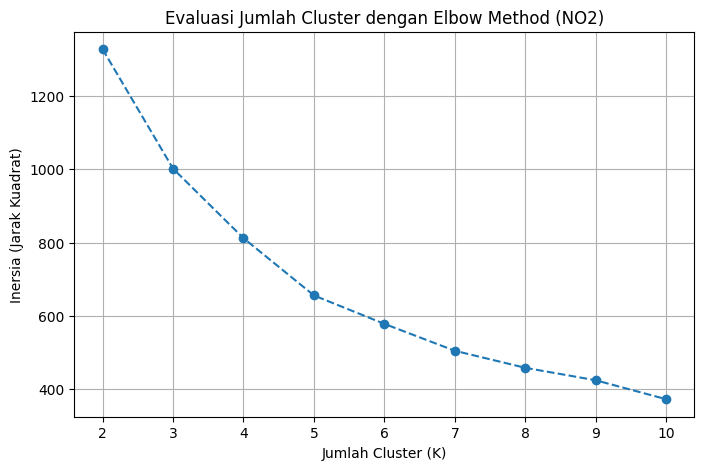

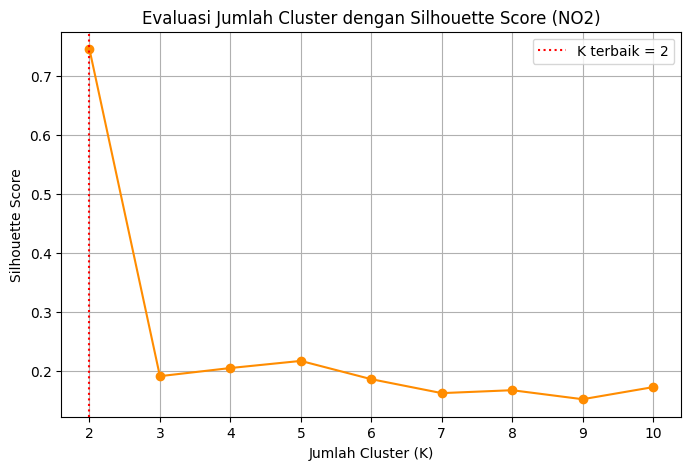

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_no2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

K_range = range(2, 11)
inertia = []
silhouette = []
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    label_temp = kmeans_temp.fit_predict(fitur_pca)
    inertia.append(kmeans_temp.inertia_)
    silhouette.append(silhouette_score(fitur_pca, label_temp))

hasil_evaluasi = pd.DataFrame({'K': list(K_range), 'Inertia': inertia, 'Silhouette Score': silhouette})
print(hasil_evaluasi.to_string(index=False))

k_terbaik = int(hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'K'])
print(f"\nK terbaik (NO2) berdasarkan Silhouette Score tertinggi: K = {k_terbaik}")

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (NO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

# Silhouette plot, dengan K terbaik ditandai
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette, marker='o', color='darkorange')
plt.axvline(k_terbaik, color='red', linestyle=':', label=f'K terbaik = {k_terbaik}')
plt.title('Evaluasi Jumlah Cluster dengan Silhouette Score (NO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- 68 fitur TSFEL (kolom `id`, `nama`, `daerah` dikeluarkan) distandardisasi dengan `StandardScaler`, lalu direduksi dengan PCA menjadi 37 komponen — jumlah maksimum yang mungkin karena data hanya 37 observasi (kecamatan).
- K-Means dijalankan untuk K = 2 sampai 10; pada tiap K dicatat `inertia_` (Elbow Method) dan `silhouette_score`.
- `k_terbaik` dipilih secara objektif sebagai K dengan Silhouette Score tertinggi, bukan dari interpretasi visual grafik elbow.
- Hasil ditampilkan pada tabel `hasil_evaluasi` dan grafik Silhouette Score dengan garis vertikal penanda `k_terbaik`, yang menjadi acuan K-Means final di bagian 3.1.

### 2.2 Evaluasi Jumlah Cluster pada CO

 K     Inertia  Silhouette Score
 2 1123.800303          0.795494
 3  660.214101          0.697034
 4  509.373825          0.342517
 5  413.889526          0.184501
 6  361.351576          0.153812
 7  315.868398          0.161337
 8  272.854136          0.142490
 9  239.322559          0.150055
10  221.039012          0.145469

K terbaik (CO) berdasarkan Silhouette Score tertinggi: K = 2


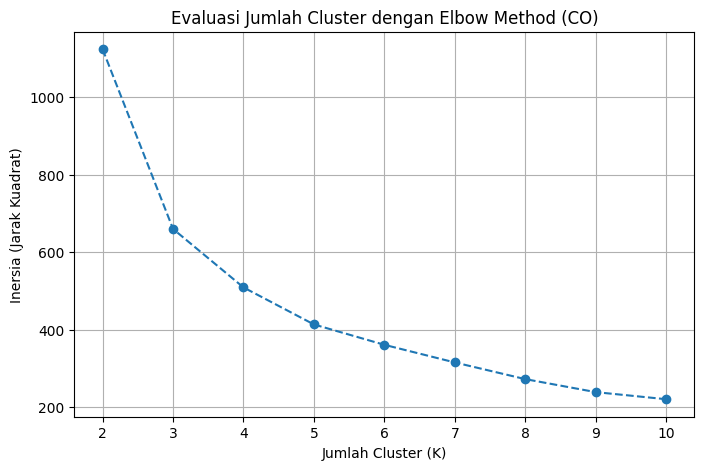

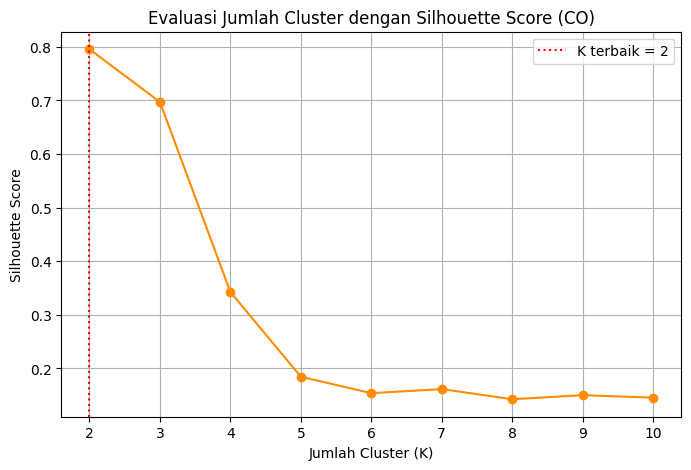

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_co.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

K_range = range(2, 11)
inertia = []
silhouette = []
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    label_temp = kmeans_temp.fit_predict(fitur_pca)
    inertia.append(kmeans_temp.inertia_)
    silhouette.append(silhouette_score(fitur_pca, label_temp))

hasil_evaluasi = pd.DataFrame({'K': list(K_range), 'Inertia': inertia, 'Silhouette Score': silhouette})
print(hasil_evaluasi.to_string(index=False))

k_terbaik = int(hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'K'])
print(f"\nK terbaik (CO) berdasarkan Silhouette Score tertinggi: K = {k_terbaik}")

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (CO)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

# Silhouette plot, dengan K terbaik ditandai
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette, marker='o', color='darkorange')
plt.axvline(k_terbaik, color='red', linestyle=':', label=f'K terbaik = {k_terbaik}')
plt.title('Evaluasi Jumlah Cluster dengan Silhouette Score (CO)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- Prosedur identik dengan subbab 2.1, hanya sumber data yang berbeda (`ekstraksi_fitur_co.csv`).
- Silhouette Score tertinggi dicapai pada K = 2 (0,795), menjadi K terbaik untuk polutan CO.

### 2.3 Evaluasi Jumlah Cluster pada SO2

 K     Inertia  Silhouette Score
 2 1210.459866          0.789366
 3  691.644801          0.708469
 4  525.289021          0.392088
 5  413.678733          0.406057
 6  335.555572          0.135855
 7  301.063844          0.126801
 8  267.415808          0.099564
 9  239.817616          0.120845
10  230.171524          0.092438

K terbaik (SO2) berdasarkan Silhouette Score tertinggi: K = 2


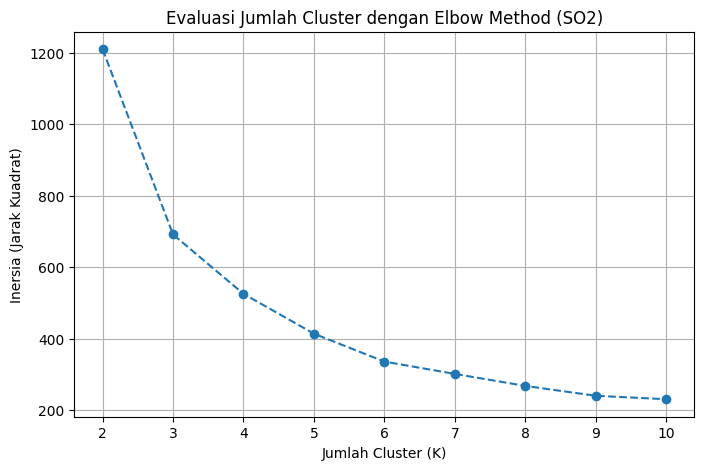

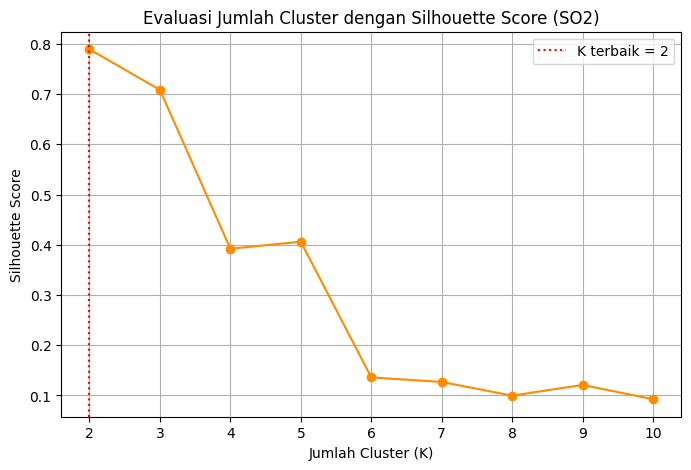

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_so2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

K_range = range(2, 11)
inertia = []
silhouette = []
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    label_temp = kmeans_temp.fit_predict(fitur_pca)
    inertia.append(kmeans_temp.inertia_)
    silhouette.append(silhouette_score(fitur_pca, label_temp))

hasil_evaluasi = pd.DataFrame({'K': list(K_range), 'Inertia': inertia, 'Silhouette Score': silhouette})
print(hasil_evaluasi.to_string(index=False))

k_terbaik = int(hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'K'])
print(f"\nK terbaik (SO2) berdasarkan Silhouette Score tertinggi: K = {k_terbaik}")

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (SO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

# Silhouette plot, dengan K terbaik ditandai
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette, marker='o', color='darkorange')
plt.axvline(k_terbaik, color='red', linestyle=':', label=f'K terbaik = {k_terbaik}')
plt.title('Evaluasi Jumlah Cluster dengan Silhouette Score (SO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- Prosedur identik dengan subbab 2.1, hanya sumber data yang berbeda (`ekstraksi_fitur_so2.csv`).
- Silhouette Score tertinggi dicapai pada K = 2 (0,789), menjadi K terbaik untuk polutan SO2.

### 2.4 Evaluasi Reduksi PCA dari 1 sampai 37 Komponen

Pada bagian 2.1-2.3, jumlah komponen PCA ditetapkan tetap pada `n_components=37`, yaitu dimensi maksimum yang dapat dibentuk mengingat jumlah sampel sebanyak 37 kecamatan. Bagian ini mengevaluasi pengaruh jumlah komponen PCA terhadap jumlah cluster optimal, dengan mencoba seluruh nilai `n_components` dari 1 hingga 37 pada ketiga polutan.

Untuk setiap polutan dan setiap nilai `n_components`, prosedurnya adalah sebagai berikut.
1. Data 68 fitur distandardisasi, kemudian direduksi dengan PCA ke `n_components` tersebut.
2. K-Means dijalankan untuk K = 2 hingga K = 10, dan Silhouette Score tertinggi di antara kesepuluh nilai K dicatat sebagai representasi kualitas cluster pada jumlah komponen tersebut.
3. Hasilnya divisualisasikan sebagai kurva Silhouette Score terhadap jumlah komponen PCA untuk ketiga polutan.

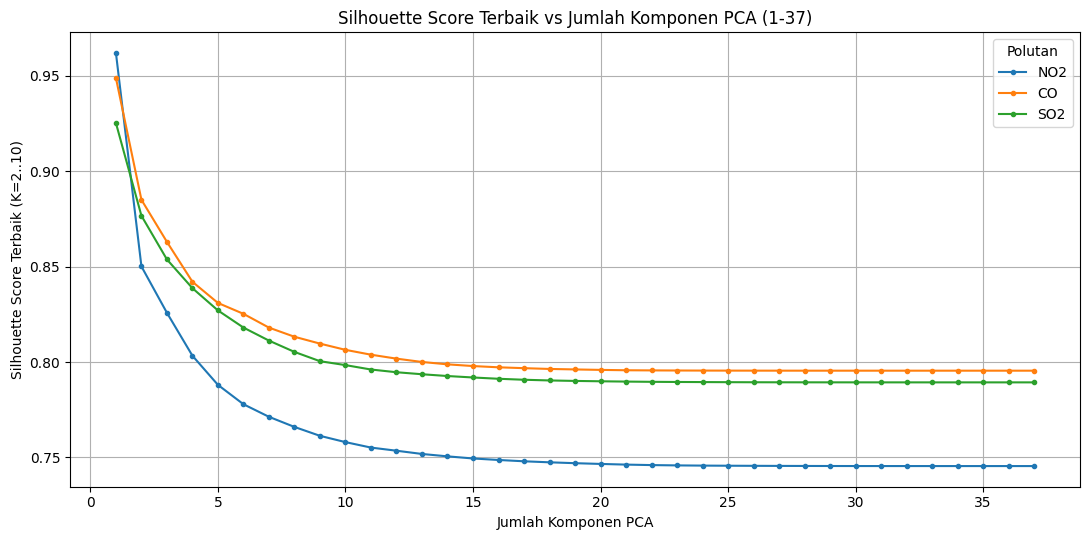

polutan  n_components_terbaik  K_terbaik  silhouette_terbaik  silhouette_pada_37_komponen  K_konsisten_2_di_semua_n_components
    NO2                     1          2            0.962038                     0.745489                                 True
     CO                     1          2            0.948900                     0.795494                                 True
    SO2                     1          2            0.925296                     0.789366                                 True


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

POLUTAN = ['NO2', 'CO', 'SO2']
FILES = {'NO2': 'ekstraksi_fitur_no2.csv', 'CO': 'ekstraksi_fitur_co.csv', 'SO2': 'ekstraksi_fitur_so2.csv'}
COLORS = {'NO2': 'tab:blue', 'CO': 'tab:orange', 'SO2': 'tab:green'}

sweep_results = {}
for pol in POLUTAN:
    df = pd.read_csv(FILES[pol])
    fitur = df.drop(['id', 'nama', 'daerah'], axis=1)
    fitur_scaled = StandardScaler().fit_transform(fitur)

    rows = []
    for n_comp in range(1, 38):
        fitur_pca = PCA(n_components=n_comp, random_state=42).fit_transform(fitur_scaled)
        best_k, best_sil = None, -1
        for k in range(2, 11):
            labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(fitur_pca)
            sil = silhouette_score(fitur_pca, labels)
            if sil > best_sil:
                best_sil, best_k = sil, k
        rows.append((n_comp, best_k, best_sil))
    sweep_results[pol] = pd.DataFrame(rows, columns=['n_components', 'K_terbaik', 'Silhouette_terbaik'])

# Plot kurva Silhouette Score terbaik vs jumlah komponen PCA, ketiga polutan sekaligus
plt.figure(figsize=(11, 5.5))
for pol in POLUTAN:
    rdf = sweep_results[pol]
    plt.plot(rdf['n_components'], rdf['Silhouette_terbaik'], marker='.', label=pol, color=COLORS[pol])
plt.title('Silhouette Score Terbaik vs Jumlah Komponen PCA (1-37)')
plt.xlabel('Jumlah Komponen PCA')
plt.ylabel('Silhouette Score Terbaik (K=2..10)')
plt.legend(title='Polutan')
plt.grid(True)
plt.tight_layout()
plt.show()

# Ringkasan: kombinasi (n_components, K) terbaik per polutan, dan nilai pada n_components=37 sebagai pembanding
summary_rows = []
for pol in POLUTAN:
    rdf = sweep_results[pol]
    top = rdf.loc[rdf['Silhouette_terbaik'].idxmax()]
    baseline = rdf.loc[rdf['n_components'] == 37].iloc[0]
    summary_rows.append({
        'polutan': pol,
        'n_components_terbaik': int(top.n_components),
        'K_terbaik': int(top.K_terbaik),
        'silhouette_terbaik': top.Silhouette_terbaik,
        'silhouette_pada_37_komponen': baseline.Silhouette_terbaik,
        'K_konsisten_2_di_semua_n_components': bool((rdf['K_terbaik'] == 2).all()),
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Penjelasan kode di atas adalah sebagai berikut.

- Pola sama untuk ketiga polutan: Silhouette Score tertinggi terjadi pada jumlah komponen paling sedikit (NO2 = 0,962; CO = 0,949; SO2 = 0,925 pada 1 komponen), lalu menurun bertahap hingga 37 komponen (mis. NO2 = 0,745, sesuai bagian 2.1-2.3).
- Pada seluruh 1-37 komponen yang diuji, K = 2 selalu menjadi K dengan Silhouette Score tertinggi (`K_konsisten_2_di_semua_n_components = True`).
- Skor tinggi pada komponen sangat sedikit bukan berarti cluster lebih baik — itu efek pemampatan data ke ruang berdimensi rendah yang membuat titik tampak lebih terpisah, padahal sebagian besar variasi asli hilang.
- Skor pada komponen lebih banyak dianggap lebih representatif karena mempertahankan lebih banyak informasi asli. Kesimpulan: jumlah cluster terbaik tetap K = 2 untuk ketiga polutan, tidak bergantung jumlah komponen PCA.

### 2.5 Evaluasi Tanpa PCA (Memakai Seluruh 68 Fitur)

Bagian ini mengulang evaluasi jumlah cluster tanpa melalui reduksi PCA; K-Means dijalankan langsung pada 68 fitur hasil standardisasi. Tujuannya adalah menguji apakah reduksi dimensi dengan PCA benar-benar mengubah hasil clustering dibandingkan dengan penggunaan seluruh fitur secara langsung.

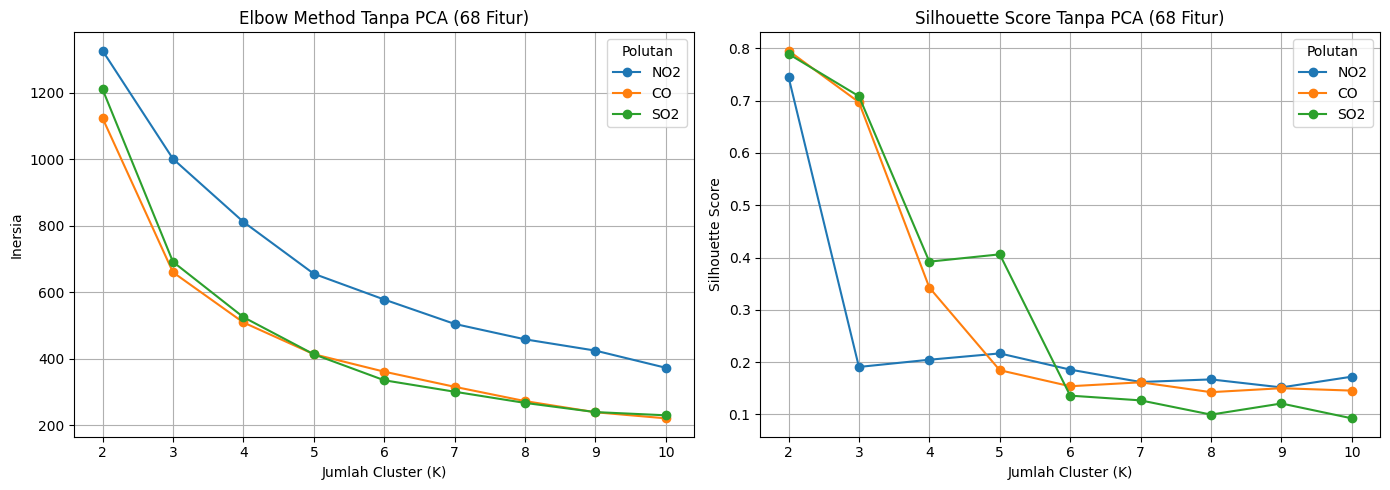

NO2: Silhouette (tanpa PCA, K=2) = 0.745489
CO: Silhouette (tanpa PCA, K=2) = 0.795494
SO2: Silhouette (tanpa PCA, K=2) = 0.789366


In [ ]:
K_range = range(2, 11)
nopca_results = {}

for pol in POLUTAN:
    df = pd.read_csv(FILES[pol])
    fitur = df.drop(['id', 'nama', 'daerah'], axis=1)
    fitur_scaled = StandardScaler().fit_transform(fitur)   # tanpa PCA, langsung 68 fitur

    inertia, sil = [], []
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(fitur_scaled)
        inertia.append(km.inertia_)
        sil.append(silhouette_score(fitur_scaled, labels))
    nopca_results[pol] = pd.DataFrame({'K': list(K_range), 'Inertia': inertia, 'Silhouette': sil})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for pol in POLUTAN:
    rdf = nopca_results[pol]
    axes[0].plot(rdf['K'], rdf['Inertia'], marker='o', label=pol, color=COLORS[pol])
    axes[1].plot(rdf['K'], rdf['Silhouette'], marker='o', label=pol, color=COLORS[pol])
axes[0].set_title('Elbow Method Tanpa PCA (68 Fitur)')
axes[0].set_xlabel('Jumlah Cluster (K)'); axes[0].set_ylabel('Inersia')
axes[0].grid(True); axes[0].legend(title='Polutan')
axes[1].set_title('Silhouette Score Tanpa PCA (68 Fitur)')
axes[1].set_xlabel('Jumlah Cluster (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True); axes[1].legend(title='Polutan')
plt.tight_layout()
plt.show()

# Bandingkan langsung dengan hasil PCA(n_components=37) pada bagian 2.1-2.3
for pol in POLUTAN:
    sil_nopca_k2 = nopca_results[pol].loc[nopca_results[pol]['K'] == 2, 'Silhouette'].values[0]
    print(f"{pol}: Silhouette (tanpa PCA, K=2) = {sil_nopca_k2:.6f}")

Penjelasan kode di atas adalah sebagai berikut.

- Struktur kode mengikuti prosedur *elbow* dan Silhouette Score pada 2.1-2.3, bedanya `fitur_scaled` langsung dipakai sebagai masukan K-Means tanpa PCA.
- Silhouette Score tanpa PCA identik hingga 6 angka desimal dengan `PCA(n_components=37)` (NO2 = 0,745489; CO = 0,795494; SO2 = 0,789366).
- Ini konsekuensi matematis, bukan kebetulan: dengan 37 sampel, PCA 37 komponen bersifat *full-rank* — hanya rotasi ruang fitur tanpa membuang informasi atau mengubah jarak antar titik, sehingga hasil K-Means dan Silhouette Score identik.
- Dengan demikian, `PCA(n_components=37)` secara matematis setara dengan memakai seluruh 68 fitur tanpa reduksi dimensi.

### 2.6 Kesimpulan Evaluasi Jumlah Cluster (Sisi Python)

Ketiga pendekatan pada bagian 2.1-2.5 — PCA tetap 37 komponen, PCA dengan jumlah komponen disapu dari 1 sampai 37, dan tanpa PCA (68 fitur penuh) — menghasilkan kesimpulan yang konsisten, dirangkum sebagai berikut.

Jumlah cluster terbaik berdasarkan Silhouette Score adalah K = 2 untuk ketiga polutan pada seluruh pendekatan yang diuji. Nilai Silhouette Score tertinggi pada representasi fitur penuh (68 fitur, setara PCA 37 komponen) berturut-turut adalah NO2 = 0,745, CO = 0,795, dan SO2 = 0,789; ketiganya tergolong tinggi, tetapi berdasarkan profil cluster pada bagian 3, nilai tersebut lebih mencerminkan keberadaan kecamatan dengan nilai fitur ekstrem (*outlier*) yang membentuk cluster tersendiri, bukan dua kelompok besar yang berimbang.

Mengingat PCA 37 komponen terbukti setara dengan penggunaan seluruh 68 fitur (bagian 2.5), dan Silhouette Score pada jumlah komponen yang sangat kecil cenderung menyesatkan (bagian 2.4), penggunaan seluruh fitur atau PCA dengan jumlah komponen menengah — misalnya dua komponen untuk keperluan visualisasi *scatter plot* pada bagian 3 — lebih disarankan dibandingkan mengandalkan Silhouette Score pada komponen tunggal.

## 3. Visualisasi Scatter Plot PCA dan Profiling

### 3.1 Visualisasi Scatter Plot PCA dan Profiling pas NO2

K terbaik (NO2) berdasarkan Silhouette Score tertinggi: K = 2 (Silhouette Score = 0.7455)


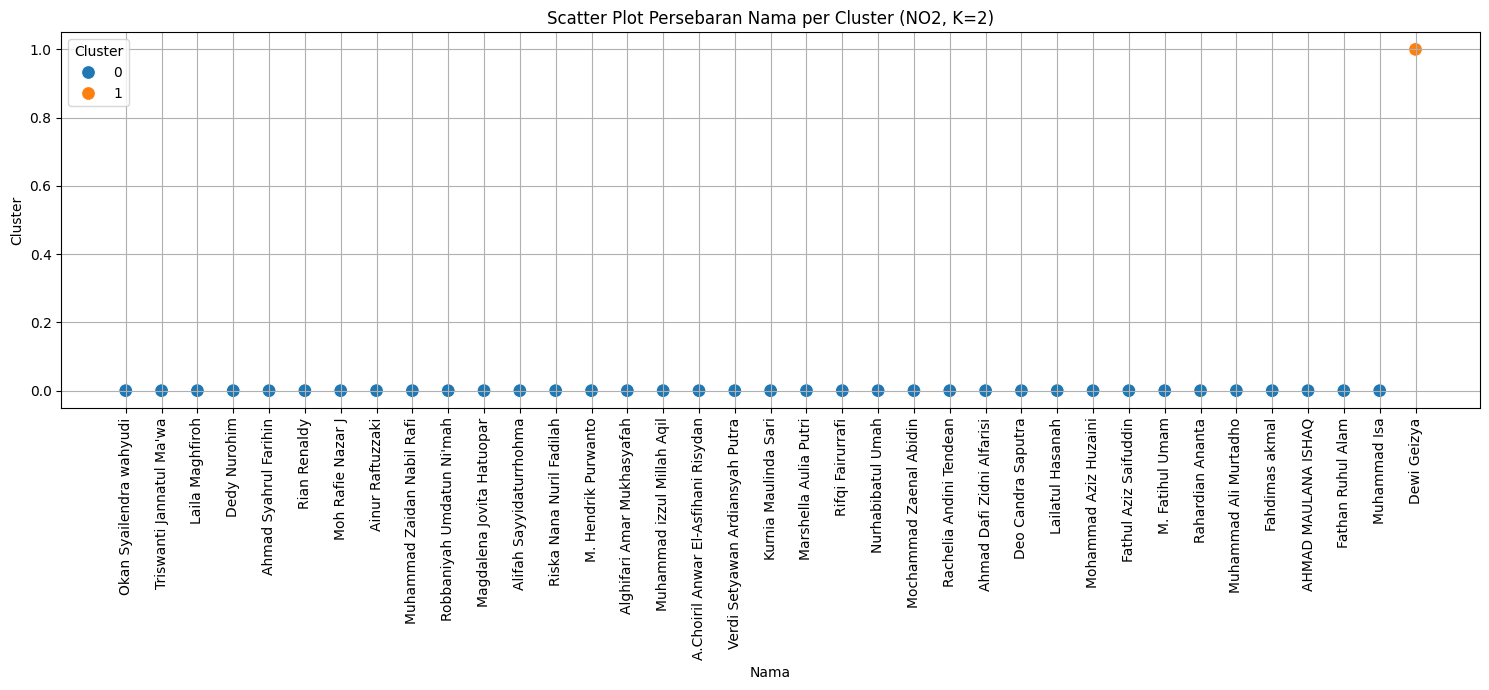

    Cluster                                 nama  Jumlah
0         0  A.Choiril Anwar El-Asfihani Risydan       1
1         0                  AHMAD MAULANA ISHAQ       1
2         0            Ahmad Dafi Zidni Alfarisi       1
36        1                          Dewi Geizya       1


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_no2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. Menentukan K terbaik berdasarkan Silhouette Score (K = 2 s.d. 10)
K_range = range(2, 11)
silhouette = []
for k in K_range:
    label_temp = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(fitur_pca)
    silhouette.append(silhouette_score(fitur_pca, label_temp))

k_terbaik = list(K_range)[silhouette.index(max(silhouette))]
print(f"K terbaik (NO2) berdasarkan Silhouette Score tertinggi: K = {k_terbaik} (Silhouette Score = {max(silhouette):.4f})")

# 4. K-Means Final menggunakan K terbaik (bukan nilai tebakan/manual)
kmeans = KMeans(n_clusters=k_terbaik, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 5. Visualisasi Scatter Plot (Sumbu X diganti ke 'nama')
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['nama'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title(f'Scatter Plot Persebaran Nama per Cluster (NO2, K={k_terbaik})')
plt.xlabel('Nama')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Menampilkan profil klaster berdasarkan nama (Top 3 per klaster)
profil_nama = df_hasil.groupby(['Cluster', 'nama']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_nama.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

Penjelasan kode di atas adalah sebagai berikut.

- K optimal untuk NO2 ditentukan dengan prosedur sama seperti 2.1: data dipisah jadi `identitas` (id, nama, daerah) dan `fitur` (68 kolom), distandardisasi, direduksi ke 37 komponen PCA.
- Silhouette Score dihitung untuk K = 2 sampai 10; K dengan skor tertinggi dipilih sebagai `k_terbaik` (data-driven, bukan manual), lalu K-Means final dijalankan.
- Hasil divisualisasikan sebagai *scatter plot* (sumbu-x nama kecamatan, sumbu-y label cluster), dilengkapi tabel tiga anggota teratas tiap cluster.

### 3.2 Visualisasi Scatter Plot PCA dan Profiling pas CO

K terbaik (CO) berdasarkan Silhouette Score tertinggi: K = 2 (Silhouette Score = 0.7955)


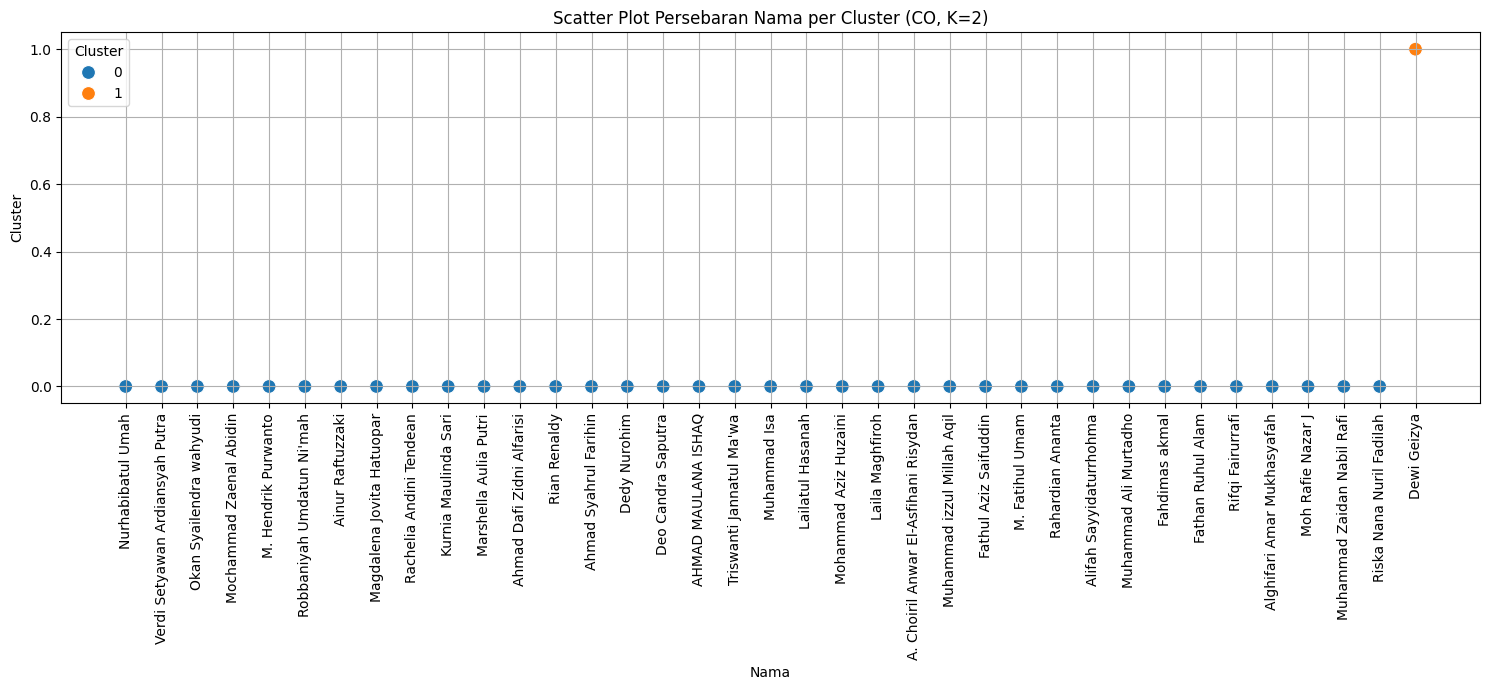

    Cluster                                  nama  Jumlah
0         0  A. Choiril Anwar El-Asfihani Risydan       1
1         0                   AHMAD MAULANA ISHAQ       1
2         0             Ahmad Dafi Zidni Alfarisi       1
36        1                           Dewi Geizya       1


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_co.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. Menentukan K terbaik berdasarkan Silhouette Score (K = 2 s.d. 10)
K_range = range(2, 11)
silhouette = []
for k in K_range:
    label_temp = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(fitur_pca)
    silhouette.append(silhouette_score(fitur_pca, label_temp))

k_terbaik = list(K_range)[silhouette.index(max(silhouette))]
print(f"K terbaik (CO) berdasarkan Silhouette Score tertinggi: K = {k_terbaik} (Silhouette Score = {max(silhouette):.4f})")

# 4. K-Means Final menggunakan K terbaik (bukan nilai tebakan/manual)
kmeans = KMeans(n_clusters=k_terbaik, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 5. Visualisasi Scatter Plot (Sumbu X diganti ke 'nama')
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['nama'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title(f'Scatter Plot Persebaran Nama per Cluster (CO, K={k_terbaik})')
plt.xlabel('Nama')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Menampilkan profil klaster berdasarkan nama (Top 3 per klaster)
profil_nama = df_hasil.groupby(['Cluster', 'nama']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_nama.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

Penjelasan kode di atas adalah sebagai berikut.

- Prosedur identik dengan subbab 3.1, hanya sumber data berbeda (`ekstraksi_fitur_co.csv`).
- K terbaik = 2 dengan Silhouette Score 0,795.

### 3.3 Visualisasi Scatter Plot PCA dan Profiling pas SO2

K terbaik (SO2) berdasarkan Silhouette Score tertinggi: K = 2 (Silhouette Score = 0.7894)


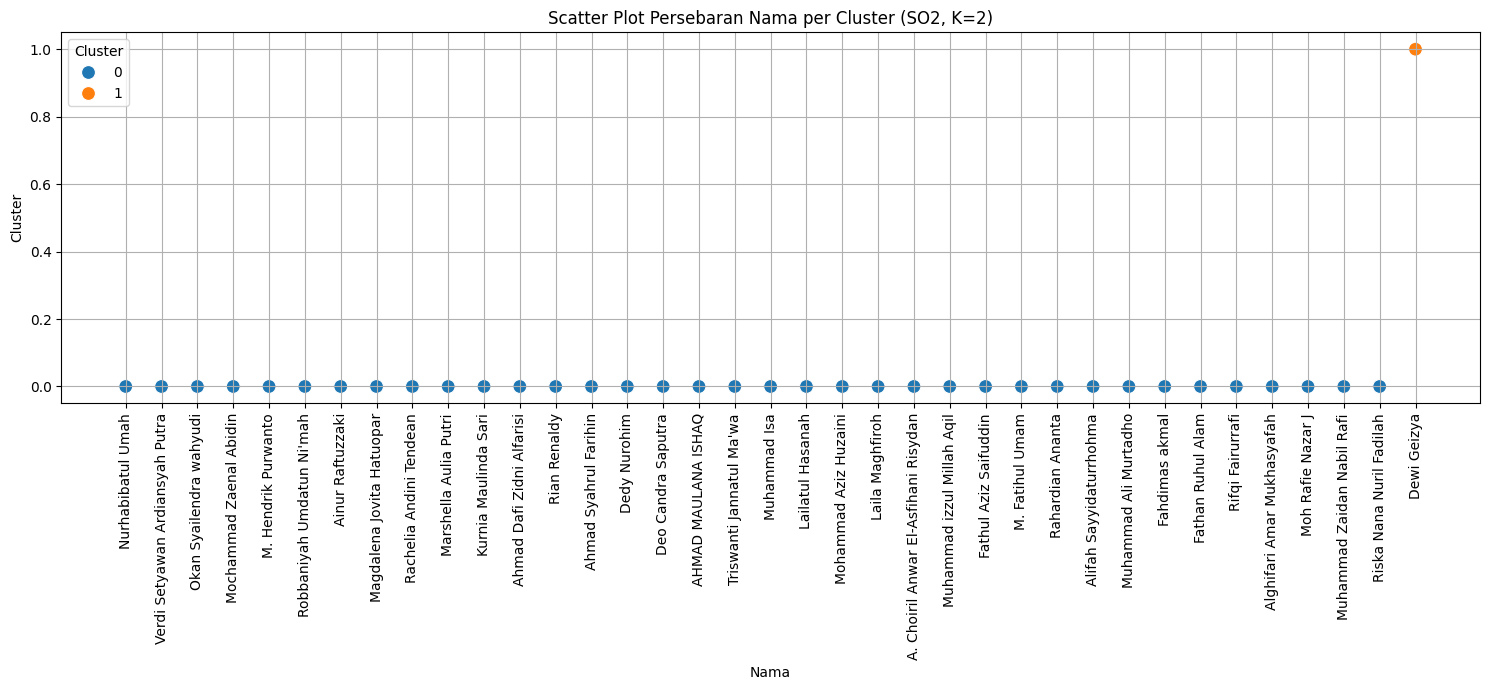

    Cluster                                  nama  Jumlah
0         0  A. Choiril Anwar El-Asfihani Risydan       1
1         0                   AHMAD MAULANA ISHAQ       1
2         0             Ahmad Dafi Zidni Alfarisi       1
36        1                           Dewi Geizya       1


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Memuat Data
df = pd.read_csv('ekstraksi_fitur_so2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. Menentukan K terbaik berdasarkan Silhouette Score (K = 2 s.d. 10)
K_range = range(2, 11)
silhouette = []
for k in K_range:
    label_temp = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(fitur_pca)
    silhouette.append(silhouette_score(fitur_pca, label_temp))

k_terbaik = list(K_range)[silhouette.index(max(silhouette))]
print(f"K terbaik (SO2) berdasarkan Silhouette Score tertinggi: K = {k_terbaik} (Silhouette Score = {max(silhouette):.4f})")

# 4. K-Means Final menggunakan K terbaik (bukan nilai tebakan/manual)
kmeans = KMeans(n_clusters=k_terbaik, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 5. Visualisasi Scatter Plot (Sumbu X diganti ke 'nama')
plt.figure(figsize=(15, 7))
sns.scatterplot(x=df_hasil['nama'], y=df_hasil['Cluster'], hue=df_hasil['Cluster'], palette='tab10', s=100)
plt.title(f'Scatter Plot Persebaran Nama per Cluster (SO2, K={k_terbaik})')
plt.xlabel('Nama')
plt.ylabel('Cluster')
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Menampilkan profil klaster berdasarkan nama (Top 3 per klaster)
profil_nama = df_hasil.groupby(['Cluster', 'nama']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_nama.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

Penjelasan kode di atas adalah sebagai berikut.

- Prosedur identik dengan subbab 3.1, hanya sumber data berbeda (`ekstraksi_fitur_so2.csv`).
- K terbaik = 2 dengan Silhouette Score 0,789.

## 4. Implementasi Alur Kerja (Workflow) Clustering KNIME

![image](https://hackmd.io/_uploads/Hk-nh88qMg.png)

Diagram di atas menampilkan alur kerja (*workflow*) K-Means Clustering yang diimplementasikan pada KNIME. Fungsi setiap *node* adalah sebagai berikut.

## 4.1  PostgreSQL Connector

PostgreSQL Connector menghubungkan KNIME dengan basis data `PSD-A` (Aiven) tempat data hasil ekstraksi fitur ketiga polutan disimpan.

> ![image](https://hackmd.io/_uploads/rJ6M1DI5zl.png)

## 4.2 DB Table Selector

DB Table Selector memilih tabel sumber data untuk masing-masing polutan; NO2, CO, dan SO2 diproses sebagai tiga cabang paralel yang terpisah. misalkan gambar di contoh memilih polutan CO.

> ![image](https://hackmd.io/_uploads/ryHhkPL5zx.png)

## 4.3 DB Reader

DB Reader membaca tabel yang dipilih ke dalam KNIME sebagai tabel data berisi 68 kolom fitur per kecamatan.

> ![image](https://hackmd.io/_uploads/BJwexwUcfl.png)

### 4.4 PCA

PCA mereduksi dimensi 68 fitur menjadi beberapa komponen utama sebelum tahap *clustering*.

> ![image](https://hackmd.io/_uploads/SJkEewIqGg.png)

## 4.5 k-Means

k-Means mengelompokkan kecamatan ke dalam *k* cluster berdasarkan komponen hasil PCA.

> ![image](https://hackmd.io/_uploads/ByV3lwU9Ge.png)

## 4. 6 Scatter Plot

Scatter Plot memvisualisasikan posisi tiap kecamatan pada bidang komponen PCA menurut label cluster.

> ![image](https://hackmd.io/_uploads/ryp0gDI9Ge.png)

## 4.7 Silhouette Coefficient

mengukur kualitas pemisahan cluster secara numerik, baik per cluster maupun secara keseluruhan.

> ![image](https://hackmd.io/_uploads/HykZbD8cfl.png)

Alur kerja di atas dijalankan secara independen untuk ketiga polutan (NO2, CO, dan SO2), sehingga proses PCA dan K-Means dilakukan terpisah pada masing-masing cabang. Hasil clustering ketiga polutan tersebut disajikan dan dibandingkan pada bagian 5.

## 5. Hasil Clustering Setiap Polutan (Scatter Plot & Silhouette Coefficient KNIME)

### 5.1 Polutan NO2 (K = 2)

**Tanpa PCA**
![image](https://hackmd.io/_uploads/rJxwP0L89Ml.png)

![Scatter Plot no2](https://hackmd.io/_uploads/S1GVKIU9Mx.png)

**Dengan PCA**
![image](https://hackmd.io/_uploads/SJ4hIIL5Mg.png)

![Scatter Plot no2](https://hackmd.io/_uploads/S1GVKIU9Mx.png)


Hasil clustering KNIME untuk NO2 identik antara representasi tanpa PCA dan dengan PCA, dengan Silhouette Coefficient rata-rata (*overall*) sebesar 0,964. Cluster mayoritas mencakup hampir seluruh kecamatan dengan silhouette tinggi (0,991), sedangkan satu cluster lain hanya beranggotakan satu kecamatan (Dewi Geizya) dengan silhouette 0, yang mengindikasikan kecamatan tersebut merupakan *outlier* dari kelompok utama. Kesamaan hasil pada kedua representasi menunjukkan bahwa reduksi dimensi PCA tidak mengubah struktur cluster yang terbentuk untuk polutan NO2.


### 5.2 Polutan CO (K = 2)

**Tanpa PCA**
![image](https://hackmd.io/_uploads/SJRgAU8qzl.png)

![Scatter Plot co](https://hackmd.io/_uploads/B1zVYL8cGl.png)

**Dengan PCA**
![image](https://hackmd.io/_uploads/HkRcvU8qfe.png)

![Scatter Plot co](https://hackmd.io/_uploads/B1zVYL8cGl.png)


Hasil clustering KNIME untuk CO juga identik antara representasi tanpa PCA dan dengan PCA, dengan Silhouette Coefficient rata-rata sebesar 0,973 — tertinggi di antara ketiga polutan. Cluster mayoritas memiliki silhouette sempurna (1,0), sedangkan cluster minoritas yang hanya beranggotakan satu kecamatan (Dewi Geizya) bersilhouette 0. Pola ini konsisten dengan NO2, yaitu adanya satu kecamatan dengan nilai fitur ekstrem yang terpisah dari kelompok utama, bukan dua kelompok besar yang terpisah secara merata.


### 5.3 Polutan SO2 (K = 2)

**Tanpa PCA**
![image](https://hackmd.io/_uploads/S15p0II9fe.png)

![Scatter Plot so2](https://hackmd.io/_uploads/ByMVKUI9Me.png)

**Dengan PCA**
![image](https://hackmd.io/_uploads/H1AOY8Ucfl.png)

![Scatter Plot so2](https://hackmd.io/_uploads/ByMVKUI9Me.png)


Hasil clustering KNIME untuk SO2 kembali identik antara representasi tanpa PCA dan dengan PCA, dengan Silhouette Coefficient rata-rata sebesar 0,969. Cluster mayoritas memiliki silhouette tinggi (0,996) dan mencakup hampir seluruh kecamatan, sedangkan cluster minoritas yang beranggotakan satu kecamatan (Dewi Geizya) bersilhouette 0. Pola ini sejalan dengan NO2 dan CO, memperkuat indikasi bahwa kecamatan tersebut merupakan *outlier* konsisten pada ketiga polutan.


## Kesimpulan

### Kesimpulan Sisi Python (Evaluasi Jumlah Cluster, bagian 2)

Jumlah cluster terbaik menurut Silhouette Score konsisten pada K = 2 untuk ketiga polutan, baik menggunakan PCA 37 komponen tetap, PCA dengan jumlah komponen disapu dari 1 sampai 37, maupun tanpa PCA sama sekali. Nilai Silhouette Score tertinggi pada representasi fitur penuh adalah NO2 = 0,745, CO = 0,795, dan SO2 = 0,789. Ketiga nilai tergolong tinggi, namun berdasarkan profil cluster pada bagian 3, hal ini lebih mencerminkan keberadaan kecamatan dengan nilai fitur ekstrem yang membentuk cluster tersendiri, bukan dua kelompok besar yang terpisah secara merata.

### Kesimpulan Sisi KNIME (bagian 4-5)

Ketiga polutan menunjukkan pola yang konsisten: pada K = 2, satu cluster mayoritas menampung hampir seluruh kecamatan dengan silhouette mendekati sempurna, sedangkan satu kecamatan (Dewi Geizya) selalu terpisah sendiri sebagai cluster minoritas bersilhouette 0. Pola ini terulang identik baik pada representasi tanpa PCA maupun dengan PCA, menunjukkan bahwa reduksi dimensi tidak mengubah hasil pengelompokan pada implementasi KNIME. Silhouette Coefficient rata-rata tertinggi diperoleh pada CO (0,973), diikuti SO2 (0,969), dan NO2 (0,964); perbedaan di antara ketiganya sangat tipis, sehingga kualitas pemisahan cluster tergolong seragam tinggi untuk ketiga polutan.

### Sintesis Python dan KNIME

Kedua pendekatan menghasilkan kesimpulan yang sejalan: hasil *clustering*, baik pada Python maupun KNIME, lebih banyak mencerminkan keberadaan kecamatan dengan nilai fitur ekstrem (*outlier*) dibandingkan segmentasi pola polusi yang merata antar kecamatan. Pada KNIME, indikasi ini lebih tegas karena kecamatan yang sama (Dewi Geizya) konsisten terpisah sebagai cluster tunggal pada ketiga polutan, baik dengan maupun tanpa PCA. Perbedaan nilai Silhouette Score antara Python dan KNIME lebih disebabkan oleh perbedaan representasi fitur dan urutan proses pada kedua alat, bukan perbedaan kesimpulan substantif mengenai struktur data.